In [5]:
from haversine import haversine, Unit
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


datas = pd.read_csv('../data/fr.csv').head(20)[["city", "lat", "lng"]]
# print(datas)

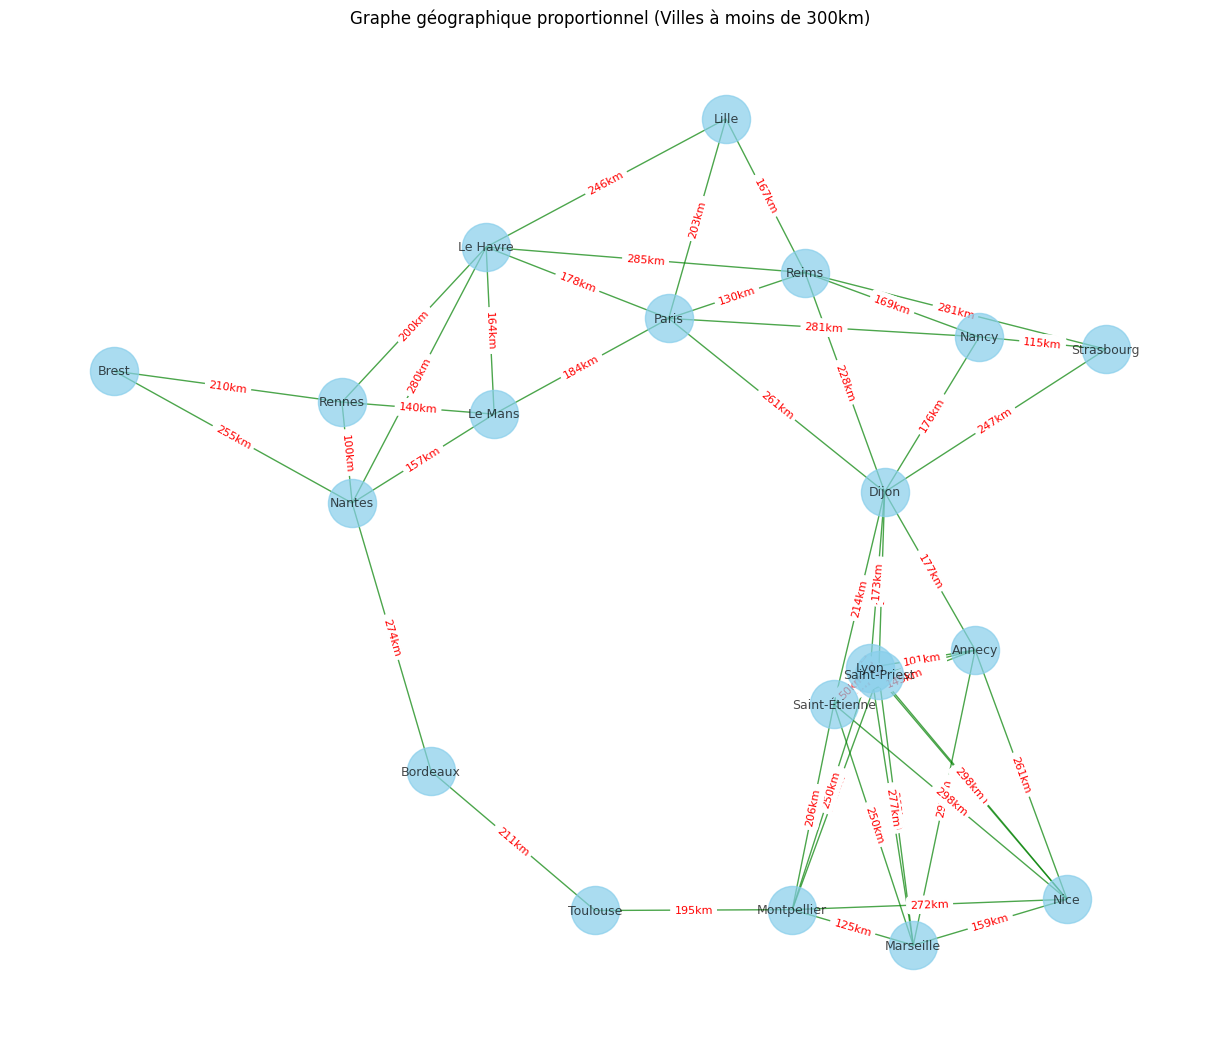

In [9]:
datas_list = datas.to_dict('records')
edges = []
formatted_labels = {}
pos = {}
for source in datas_list:
    pos[source["city"]] = (float(source["lng"]), float(source["lat"]))
    temp_dist = []
    for target in datas_list:
        if source["city"] != target["city"] :

            cor_source = (float(source["lat"]), float(source["lng"]))
            cor_target = (float(target["lat"]), float(target["lng"]))
            d = haversine(cor_source, cor_target)
            if d < 300:
                edges.append((source["city"], target["city"], d))
                formatted_labels[(source["city"], target["city"])] = f"{int(d)}km"

G = nx.Graph()
G.add_weighted_edges_from(edges)

plt.figure(figsize=(12, 10))

# 3. Affichage
nx.draw(G, pos,
        with_labels=True,
        node_color='skyblue',
        node_size=1200,
        font_size=9,
        edge_color="green",
        alpha=0.7)

nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_labels, font_color='red', font_size=8)

plt.title("Graphe géographique proportionnel (Villes à moins de 300km)")
plt.show()